# Biodiversity and Conservation Analysis

## 1. Project Purpose:
This project uses Python to examine biodiversity and conservation data associated with four United States national parks. The analysis will investigate species composition, conservation status, listed conservation rates, and recorded observations while checking whether duplicate records or unsafe joins could affect the results.

## 2. Questions:
1. How many unique species are represented, and how are they distributed across biological categories?

2. How are conservation statuses distributed among the recorded species?

3. Which biological categories have the highest percentage of unique species with a recorded conservation status?

4. Are differences in protection rates between selected categories statistically significant?

5. How do recorded observations vary across the four parks?

6. Are there data-quality issues that could change the analytical conclusions?

## 3. Limitations:
- The data is inspired by National Park Service information but is mostly fictional.

- The observation data represents only a seven-day period.

- There are no dates, historical comparison periods, or seasonal information.

- The data does not provide park area or wildlife-survey effort.

- An observation count is not necessarily the same as the number of individual animals or plants.

- Comparisons between parks cannot establish that one park has greater biodiversity or better conservation performance.

- Relationships found in the data should not be interpreted as causal.

## 4. Datasets Inspection:

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')

In [94]:
PROJECT_DIR = Path.cwd()

species_path = PROJECT_DIR / "species_info.csv"
observations_path = PROJECT_DIR / "observations.csv"

In [13]:
species = pd.read_csv(species_path)
observations = pd.read_csv(observations_path)

print(f'species rows and columns: {species.shape}')
print(f'observations rows and columns: {observations.shape}')

species rows and columns: (5824, 4)
observations rows and columns: (23296, 3)


In [27]:
print(species.head(10))
print(observations.head(10))

species.info()
observations.info()

print(species.describe(include='all').T)
print(observations.describe(include='all').T)

  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   
5   Mammal         Odocoileus virginianus   
6   Mammal                     Sus scrofa   
7   Mammal                  Canis latrans   
8   Mammal                    Canis lupus   
9   Mammal                    Canis rufus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole                 NaN  
1                              American Bison, Bison                 NaN  
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...                 NaN  
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)                 NaN  
4                                      Wapiti Or Elk                 NaN  
5                                  White-Tailed Deer  

In [22]:
print('unique values in species dataset:')
display(species.nunique(dropna=False))

print('\nunique values in observations dataset:')
display(observations.nunique(dropna=False))

unique values in species dataset:


category                  7
scientific_name        5541
common_names           5504
conservation_status       5
dtype: int64


unique values in observations dataset:


scientific_name    5541
park_name             4
observations        304
dtype: int64

In [26]:
print('species categories:')
display(species['category'].nunique(dropna=False))

print('\nobservation statuses:')
display(species['conservation_status'].nunique(dropna=False))

print('\nnational parks:')
display(observations['park_name'].nunique(dropna=False))

species categories:


7


observation statuses:


5


national parks:


4

### Initial Observations:
- `species_info.csv` contains species classification, common names, and conservation-status records.
- `observations.csv` contains recorded observation counts for scientific names at four parks.
- The datasets can be connected using `scientific_name`.
- There are 5,824 species records but only 5,541 unique scientific names, indicating that some names appear multiple times. These repetitions require further investigation before joining the datasets.
- `conservation_status` is the only column with missing values.
- Recorded observation counts range from 9 to 321 per row.

## 5. Data Quality Audit:

In [29]:
def missing_summary(dataframe):
    return pd.DataFrame({
        'missing_count': dataframe.isna().sum(),
        'missing_percent': dataframe.isna().mean() * 100})

display(missing_summary(species))
display(missing_summary(observations))

,missing_count,missing_percent
category,0,0.00
scientific_name,0,0.00
common_names,0,0.00
conservation_status,5633,96.72


,missing_count,missing_percent
scientific_name,0,0.00
park_name,0,0.00
observations,0,0.00


In [30]:
print('The number of duplicate rows for species: ', species.duplicated().sum())
print('The number of duplicate rows for observations: ', observations.duplicated().sum())

The number of duplicate rows for species:  0
The number of duplicate rows for observations:  15


In [31]:
# Test whether scientific names are unique
species_name_counts = (
    species.groupby('scientific_name').size().sort_values(ascending=False)
)

print('Unique scientific names:', species['scientific_name'].nunique())

print('Scientific names appear more than once:', 
      (species_name_counts > 1).sum()
     )

print('Rows belong to repeated names:', 
      species['scientific_name'].duplicated(keep=False).sum()
     )

Unique scientific names: 5541
Scientific names appear more than once: 274
Rows belong to repeated names: 557


In [32]:
# Conflicted Classifications:
species_consistency = (
    species.assign(
        conservation_status_check=
            species["conservation_status"].fillna("No recorded status")
    )
    .groupby("scientific_name")
    .agg(
        category_count=("category", "nunique"),
        common_name_count=("common_names", "nunique"),
        status_count=("conservation_status_check", "nunique")
    )
)

conflicting_species = species_consistency[
    (species_consistency["category_count"] > 1)
    | (species_consistency["status_count"] > 1)
]

display(conflicting_species)

,category_count,common_name_count,status_count
scientific_name,,,
Canis lupus,1,2,2
Oncorhynchus mykiss,1,1,2


In [39]:
observations_key_counts = (
    observations.groupby(['scientific_name', 'park_name']).size().reset_index(name='row_count'))

duplicate_observation_keys = observations_key_counts[
    observations_key_counts['row_count'] > 1]

print('repeated scientific names and park names: ', len(duplicated_observation_keys))

print('\nrows belong to repeated combinations: ',
      observations.duplicated(
          subset = ['scientific_name', 'park_name'],
          keep=False
      ).sum()
     )
          
display(
    duplicate_observation_keys
    .sort_values("row_count", ascending=False)
    .head(10)
)

repeated scientific names and park names:  1096

rows belong to repeated combinations:  2228


,scientific_name,park_name,row_count
16717,Puma concolor,Great Smoky Mountains National Park,3
9811,Holcus lanatus,Yosemite National Park,3
3217,Canis lupus,Great Smoky Mountains National Park,3
3216,Canis lupus,Bryce National Park,3
19973,Streptopelia decaocto,Great Smoky Mountains National Park,3
19974,Streptopelia decaocto,Yellowstone National Park,3
19975,Streptopelia decaocto,Yosemite National Park,3
13290,Myotis lucifugus,Yellowstone National Park,3
9808,Holcus lanatus,Bryce National Park,3
9809,Holcus lanatus,Great Smoky Mountains National Park,3


In [42]:
display(observations['observations'].describe())

print('Missing observation counts:', 
      observations['observations'].isna().sum())

print(
    "Zero or negative observation counts:",
    (observations["observations"] <= 0).sum()
)

print(
    "Non-integer observation values:",
    (observations["observations"] % 1 != 0).sum()
)

count   23,296.00
mean       142.29
std         69.89
min          9.00
25%         86.00
50%        124.00
75%        195.00
max        321.00
Name: observations, dtype: float64

Missing observation counts: 0
Zero or negative observation counts: 0
Non-integer observation values: 0


In [43]:
species_names = set(species["scientific_name"])
observation_names = set(observations["scientific_name"])

print(
    "Species missing from observations:",
    len(species_names - observation_names)
)

print(
    "Observation names missing from species:",
    len(observation_names - species_names)
)

Species missing from observations: 0
Observation names missing from species: 0


### Data-quality findings:
- The species file contains 5,824 records representing 5,541 unique scientific names.
- Scientific name is not a unique key: 274 names occur more than once.
- Repeated scientific names sometimes have different common names, and two have conflicting conservation-status records.
- The observations file contains 15 exact duplicate rows, but the lack of record identifiers prevents determining whether they are accidental duplicates.
- There are 1,096 repeated scientific-name and park combinations, so the observations must be aggregated before joining.
- Observation counts contain no missing, zero, negative, or non-integer values.
- All scientific names are represented in both datasets.

## 6. Analysis Table:

In [45]:
# Preserve the raw datasets:
species_raw = species.copy()
observations_raw = observations.copy()

In [46]:
species_work = species_raw.copy()

species_work['conservation_status_clean'] = species_work['conservation_status'].fillna('No recorded status')

In [47]:
status_priority = {
    "No recorded status": 0,
    "Species of Concern": 1,
    "In Recovery": 2,
    "Threatened": 3,
    "Endangered": 4
}

species_work["status_priority"] = (
    species_work["conservation_status_clean"]
    .map(status_priority)
)

In [49]:
display(
    species_work[species_work["scientific_name"].isin(
            ["Canis lupus", "Oncorhynchus mykiss"]
        )
    ].sort_values(
        ["scientific_name", "status_priority"],
        ascending=[True, False]
    )
)

,category,scientific_name,common_names,conservation_status,conservation_status_clean,status_priority
8,Mammal,Canis lupus,Gray Wolf,Endangered,Endangered,4
4448,Mammal,Canis lupus,"Gray Wolf, Wolf",Endangered,Endangered,4
3020,Mammal,Canis lupus,"Gray Wolf, Wolf",In Recovery,In Recovery,2
3283,Fish,Oncorhynchus mykiss,Rainbow Trout,Threatened,Threatened,3
560,Fish,Oncorhynchus mykiss,Rainbow Trout,NaN,No recorded status,0


In [50]:
species_sorted = species_work.sort_values(
    ["scientific_name", "status_priority"],
    ascending=[True, False]
)

In [51]:
canonical_species = (
    species_sorted
    .groupby("scientific_name", as_index=False, sort=False)
    .agg(
        category=("category", "first"),
        common_names=(
            "common_names",
            lambda values: " | ".join(sorted(set(values)))
        ),
        conservation_status=(
            "conservation_status_clean",
            "first"
        ),
        original_record_count=("scientific_name", "size"),
        category_count=("category", "nunique"),
        status_count=("conservation_status_clean", "nunique")
    )
)

In [52]:
canonical_species["has_recorded_status"] = (
    canonical_species["conservation_status"]
    != "No recorded status"
)

canonical_species["status_conflict"] = (
    canonical_species["status_count"] > 1
)

In [53]:
print("Canonical species rows:", len(canonical_species))
print(
    "Scientific name is unique:",
    canonical_species["scientific_name"].is_unique
)
print(
    "Status conflicts retained:",
    canonical_species["status_conflict"].sum()
)
print(
    "Category conflicts:",
    (canonical_species["category_count"] > 1).sum()
)

Canonical species rows: 5541
Scientific name is unique: True
Status conflicts retained: 2
Category conflicts: 0


In [54]:
observations_clean = (
    observations_raw
    .groupby(
        ["scientific_name", "park_name"],
        as_index=False,
        sort=False
    )
    .agg(
        observations=("observations", "sum"),
        source_row_count=("observations", "size")
    )
)

print("Original observation rows:", len(observations_raw))
print("Aggregated observation rows:", len(observations_clean))

print(
    "Original observation total:",
    observations_raw["observations"].sum()
)

print(
    "Aggregated observation total:",
    observations_clean["observations"].sum()
)

Original observation rows: 23296
Aggregated observation rows: 22164
Original observation total: 3314739
Aggregated observation total: 3314739


In [58]:
naive_join = observations_raw.merge(
    species_raw,
    on="scientific_name"
)

naive_total = naive_join["observations"].sum()
correct_total = observations_raw["observations"].sum()

join_inflation_percent = (
    (naive_total / correct_total) - 1
) * 100

print("Original rows:", len(observations_raw))
print("Naive-join rows:", len(naive_join))
print("Original observation total:", correct_total)
print("Naive-join observation total:", naive_total)
print(f"Join inflation: {join_inflation_percent:.2f}%")

Original rows: 23296
Naive-join rows: 25632
Original observation total: 3314739
Naive-join observation total: 3645247
Join inflation: 9.97%


In [59]:
del naive_join

In [56]:
species_park = observations_clean.merge(
    canonical_species,
    on='scientific_name',
    how='left',
    validate='many_to_one',
    indicator=True
)

In [57]:
print("Rows before merge:", len(observations_clean))
print("Rows after merge:", len(species_park))

print("\nMerge results:")
print(species_park["_merge"].value_counts())

print(
    "\nTotal before merge:",
    observations_clean["observations"].sum()
)

print(
    "Total after merge:",
    species_park["observations"].sum()
)

Rows before merge: 22164
Rows after merge: 22164

Merge results:
_merge
both          22164
left_only         0
right_only        0
Name: count, dtype: int64

Total before merge: 3314739
Total after merge: 3314739


### Cleaning and integration decisions

A direct merge on `scientific_name` produced a many-to-many relationship, increasing the observation total by 9.97%. To prevent this, I created a canonical species table with one row per scientific name and aggregated observations to one row per scientific-name and park combination.

Two scientific names contained conflicting conservation statuses. These conflicts were retained in a flag, and the more conservative recorded status was selected for the canonical table. The final merge was validated as many-to-one and preserved all 3,314,739 recorded observations.

The 15 exact observation duplicates were retained because the dataset does not contain record identifiers or survey timestamps that would determine whether they are accidental duplicates. This remains a limitation of the analysis.

## 7. Analyze Species and Conservation Distributions:

In [67]:
category_summary = (
    canonical_species["category"].value_counts()
    .rename_axis("category").reset_index(name="species_count")
)

category_summary["percent_of_species"] = (
    category_summary["species_count"]
    / category_summary["species_count"].sum()
    * 100
)

display(category_summary)

,category,species_count,percent_of_species
0,Vascular Plant,4262,76.92
1,Bird,488,8.81
2,Nonvascular Plant,333,6.01
3,Mammal,176,3.18
4,Fish,125,2.26
5,Amphibian,79,1.43
6,Reptile,78,1.41


In [62]:
status_summary = (
    canonical_species["conservation_status"]
    .value_counts()
    .rename_axis("conservation_status")
    .reset_index(name="species_count")
)

status_summary["percent_of_species"] = (
    status_summary["species_count"]
    / status_summary["species_count"].sum()
    * 100
)

display(status_summary)

,conservation_status,species_count,percent_of_species
0,No recorded status,5362,96.77
1,Species of Concern,151,2.73
2,Endangered,15,0.27
3,Threatened,10,0.18
4,In Recovery,3,0.05


In [68]:
recorded_status_count = canonical_species['has_recorded_status'].sum()

recorded_status_percent = (
    canonical_species['has_recorded_status'].mean() * 100
)

print("Unique species with a recorded status:",
    recorded_status_count
)

print(
    f"Percentage with a recorded status: "
    f"{recorded_status_percent:.2f}%"
)

Unique species with a recorded status: 179
Percentage with a recorded status: 3.23%


In [69]:
recorded_status_summary = (
    canonical_species.loc[
        canonical_species["has_recorded_status"],
        "conservation_status"
    ]
    .value_counts()
    .rename_axis("conservation_status")
    .reset_index(name="species_count")
)

recorded_status_summary["percent_of_recorded_statuses"] = (
    recorded_status_summary["species_count"]
    / recorded_status_summary["species_count"].sum()
    * 100
)

display(recorded_status_summary)

,conservation_status,species_count,percent_of_recorded_statuses
0,Species of Concern,151,84.36
1,Endangered,15,8.38
2,Threatened,10,5.59
3,In Recovery,3,1.68


In [70]:
raw_status_counts = (
    species_work["conservation_status_clean"]
    .value_counts()
    .rename("raw_record_count")
)

canonical_status_counts = (
    canonical_species["conservation_status"]
    .value_counts()
    .rename("unique_species_count")
)

status_count_comparison = (
    pd.concat(
        [raw_status_counts, canonical_status_counts],
        axis=1
    )
    .fillna(0)
    .astype(int)
)

status_count_comparison["difference"] = (
    status_count_comparison["raw_record_count"]
    - status_count_comparison["unique_species_count"]
)

display(status_count_comparison)

,raw_record_count,unique_species_count,difference
No recorded status,5633,5362,271
Species of Concern,161,151,10
Endangered,16,15,1
Threatened,10,10,0
In Recovery,4,3,1


In [71]:
category_status_table = pd.crosstab(
    canonical_species["category"],
    canonical_species["conservation_status"]
)

display(category_status_table)

conservation_status,Endangered,In Recovery,No recorded status,Species of Concern,Threatened
category,,,,,
Amphibian,1,0,72,4,2
Bird,4,3,413,68,0
Fish,3,0,114,4,4
Mammal,6,0,146,22,2
Nonvascular Plant,0,0,328,5,0
Reptile,0,0,73,5,0
Vascular Plant,1,0,4216,43,2


In [72]:
category_status_table_with_total = pd.crosstab(
    canonical_species["category"],
    canonical_species["conservation_status"],
    margins=True,
    margins_name="Total"
)

display(category_status_table_with_total)

conservation_status,Endangered,In Recovery,No recorded status,Species of Concern,Threatened,Total
category,,,,,,
Amphibian,1,0,72,4,2,79
Bird,4,3,413,68,0,488
Fish,3,0,114,4,4,125
Mammal,6,0,146,22,2,176
Nonvascular Plant,0,0,328,5,0,333
Reptile,0,0,73,5,0,78
Vascular Plant,1,0,4216,43,2,4262
Total,15,3,5362,151,10,5541


### Species and conservation distribution

The canonical dataset contains 5,541 unique scientific names. Vascular plants account for 4,262 species, approximately 76.9% of the dataset, making them substantially more represented than any other category.

A total of 179 unique species, or 3.23%, have a recorded conservation status. Among these species, 151 are classified as Species of Concern, making this the most common recorded status.

The raw species file contains repeated scientific names, so counting raw rows overstates the number of unique species in several conservation categories. Consequently, all species-level distributions were calculated from the canonical one-row-per-scientific-name table.

These results describe the composition of this dataset and should not be treated as an estimate of biodiversity or conservation prevalence across all National Park Service lands.

## 8. Conservation-Status Rates

In [75]:
conservation_by_category = (
    canonical_species
    .groupby("category")
    .agg(
        total_species=("scientific_name", "size"),
        species_with_status=("has_recorded_status", "sum")
    )
)

conservation_by_category["no_recorded_status"] = (
    conservation_by_category["total_species"]
    - conservation_by_category["species_with_status"]
)

conservation_by_category["recorded_status_rate"] = (
    conservation_by_category["species_with_status"]
    / conservation_by_category["total_species"]
    * 100
)

conservation_by_category = (
    conservation_by_category
    .sort_values("recorded_status_rate", ascending=False)
    .reset_index()
)

display(conservation_by_category)

,category,total_species,species_with_status,no_recorded_status,recorded_status_rate
0,Mammal,176,30,146,17.05
1,Bird,488,75,413,15.37
2,Amphibian,79,7,72,8.86
3,Fish,125,11,114,8.80
4,Reptile,78,5,73,6.41
5,Nonvascular Plant,333,5,328,1.50
6,Vascular Plant,4262,46,4216,1.08


In [76]:
print(
    conservation_by_category[
        ["total_species", "species_with_status"]
    ].sum()
)

total_species          5541
species_with_status     179
dtype: int64


### Conservation-status rates by category

Mammals have the highest recorded conservation-status rate at 17.05%, followed by birds at 15.37%. Although vascular plants have 46 species with recorded statuses—more than mammals—their rate is only 1.08% because the dataset contains 4,262 vascular plant species.

This demonstrates why both counts and rates should be considered. Absolute counts show the number of listed species, while rates account for the total number of species represented in each category.

These percentages describe recorded conservation statuses in this fictional dataset. They do not measure the categories' true extinction risk or determine why the differences exist.

## 9. Test Differences Between Categories:

In [77]:
from scipy.stats import fisher_exact

In [78]:
def compare_categories(category_a, category_b):
    selected_species = canonical_species[
        canonical_species["category"].isin(
            [category_a, category_b]
        )
    ]

    contingency_table = pd.crosstab(
        selected_species["category"],
        selected_species["has_recorded_status"]
    ).reindex(
        index=[category_a, category_b],
        columns=[True, False],
        fill_value=0
    )

    odds_ratio, p_value = fisher_exact(
        contingency_table.to_numpy()
    )

    a = contingency_table.loc[category_a, True]
    b = contingency_table.loc[category_a, False]
    c = contingency_table.loc[category_b, True]
    d = contingency_table.loc[category_b, False]

    rate_a = a / (a + b)
    rate_b = c / (c + d)
    risk_ratio = rate_a / rate_b

    standard_error = np.sqrt(
        (1 / a)
        - (1 / (a + b))
        + (1 / c)
        - (1 / (c + d))
    )

    confidence_lower = np.exp(
        np.log(risk_ratio) - 1.96 * standard_error
    )

    confidence_upper = np.exp(
        np.log(risk_ratio) + 1.96 * standard_error
    )

    result = {
        "comparison": f"{category_a} vs {category_b}",
        "rate_a_percent": rate_a * 100,
        "rate_b_percent": rate_b * 100,
        "risk_ratio": risk_ratio,
        "risk_ratio_ci_lower": confidence_lower,
        "risk_ratio_ci_upper": confidence_upper,
        "odds_ratio": odds_ratio,
        "p_value": p_value
    }

    return contingency_table, result

In [79]:
comparisons = [
    ("Mammal", "Bird"),
    ("Mammal", "Reptile")
]

pairwise_results = []

for category_a, category_b in comparisons:
    table, result = compare_categories(
        category_a,
        category_b
    )

    print(f"\n{category_a} versus {category_b}")
    display(table)

    pairwise_results.append(result)

pairwise_results = pd.DataFrame(pairwise_results)

display(pairwise_results)


Mammal versus Bird


has_recorded_status,True,False
category,,
Mammal,30,146
Bird,75,413



Mammal versus Reptile


has_recorded_status,True,False
category,,
Mammal,30,146
Reptile,5,73


,comparison,rate_a_percent,rate_b_percent,risk_ratio,risk_ratio_ci_lower,risk_ratio_ci_upper,odds_ratio,p_value
0,Mammal vs Bird,17.05,15.37,1.11,0.75,1.63,1.13,0.63
1,Mammal vs Reptile,17.05,6.41,2.66,1.07,6.60,3.00,0.03


In [80]:
number_of_tests = len(pairwise_results)

pairwise_results["adjusted_p_value"] = np.minimum(
    pairwise_results["p_value"] * number_of_tests,
    1
)

pairwise_results["significant_after_adjustment"] = (
    pairwise_results["adjusted_p_value"] < 0.05
)

display(
    pairwise_results[
        [
            "comparison",
            "rate_a_percent",
            "rate_b_percent",
            "risk_ratio",
            "risk_ratio_ci_lower",
            "risk_ratio_ci_upper",
            "p_value",
            "adjusted_p_value",
            "significant_after_adjustment"
        ]
    ]
)

,comparison,rate_a_percent,rate_b_percent,risk_ratio,risk_ratio_ci_lower,risk_ratio_ci_upper,p_value,adjusted_p_value,significant_after_adjustment
0,Mammal vs Bird,17.05,15.37,1.11,0.75,1.63,0.63,1.00,False
1,Mammal vs Reptile,17.05,6.41,2.66,1.07,6.60,0.03,0.06,False


### Statistical comparisons

Fisher's exact tests were used because some conservation-status counts were small. Mammals and birds had recorded-status rates of 17.05% and 15.37%, respectively. The difference was not statistically significant (`p = 0.630`).

Mammals had a higher observed rate than reptiles—17.05% compared with 6.41%—with a risk ratio of 2.66. The unadjusted Fisher p-value was 0.029. After correcting for two comparisons, the p-value increased to 0.058, so the result was treated as suggestive rather than conclusive.

These comparisons concern recorded conservation statuses in this dataset. They do not establish biological vulnerability, causality, or differences across the complete populations of these taxonomic groups.

## 10. Analyze Recorded Observations:

In [81]:
park_summary = (
    species_park
    .groupby("park_name")
    .agg(
        total_observations=("observations", "sum"),
        unique_species=("scientific_name", "nunique"),
        mean_per_species=("observations", "mean"),
        median_per_species=("observations", "median")
    )
    .sort_values("total_observations", ascending=False)
    .reset_index()
)

park_summary["share_of_observations"] = (
    park_summary["total_observations"]
    / park_summary["total_observations"].sum()
    * 100
)

display(park_summary)

,park_name,total_observations,unique_species,mean_per_species,median_per_species,share_of_observations
0,Yellowstone National Park,1443562,5541,260.52,250.00,43.55
1,Yosemite National Park,863332,5541,155.81,150.00,26.05
2,Bryce National Park,576025,5541,103.96,100.00,17.38
3,Great Smoky Mountains National Park,431820,5541,77.93,75.00,13.03


In [82]:
species_coverage_by_park = (
    species_park
    .groupby("park_name")
    ["scientific_name"]
    .nunique()
    .sort_values(ascending=False)
)

display(species_coverage_by_park)

park_name
Bryce National Park                    5541
Great Smoky Mountains National Park    5541
Yellowstone National Park              5541
Yosemite National Park                 5541
Name: scientific_name, dtype: int64

In [83]:
category_observation_summary = (
    species_park
    .groupby("category")
    .agg(
        total_observations=("observations", "sum"),
        unique_species=("scientific_name", "nunique"),
        mean_species_park_count=("observations", "mean"),
        median_species_park_count=("observations", "median")
    )
    .sort_values("total_observations", ascending=False)
    .reset_index()
)

category_observation_summary["observation_share"] = (
    category_observation_summary["total_observations"]
    / category_observation_summary["total_observations"].sum()
    * 100
)

display(category_observation_summary)

,category,total_observations,unique_species,mean_species_park_count,median_species_park_count,observation_share
0,Vascular Plant,2555090,4262,149.88,129.00,77.08
1,Bird,292833,488,150.02,129.00,8.83
2,Nonvascular Plant,190653,333,143.13,126.00,5.75
3,Mammal,116696,176,165.76,134.00,3.52
4,Fish,70818,125,141.64,120.50,2.14
5,Reptile,44678,78,143.20,123.00,1.35
6,Amphibian,43971,79,139.15,117.00,1.33


In [84]:
species_observation_summary = (
    species_park
    .groupby(
        ["scientific_name", "category"],
        as_index=False
    )
    .agg(
        total_observations=("observations", "sum")
    )
    .sort_values(
        "total_observations",
        ascending=False
    )
)

top_10_species = species_observation_summary.head(10)

display(top_10_species)

,scientific_name,category,total_observations
4993,Streptopelia decaocto,Bird,1785
2452,Holcus lanatus,Vascular Plant,1780
1103,Castor canadensis,Mammal,1725
2555,Hypochaeris radicata,Vascular Plant,1720
4179,Puma concolor,Mammal,1711
4109,Procyon lotor,Mammal,1692
1359,Columba livia,Bird,1653
3322,Myotis lucifugus,Mammal,1547
583,Bidens tripartita,Vascular Plant,1296
3494,Oxalis dillenii,Vascular Plant,1276


In [85]:
status_observation_summary = (
    species_park
    .groupby("has_recorded_status")
    .agg(
        total_observations=("observations", "sum"),
        unique_species=("scientific_name", "nunique"),
        species_park_rows=("observations", "size"),
        mean_species_park_count=("observations", "mean"),
        median_species_park_count=("observations", "median")
    )
    .reset_index()
)

status_observation_summary["observation_share"] = (
    status_observation_summary["total_observations"]
    / status_observation_summary["total_observations"].sum()
    * 100
)

display(status_observation_summary)

,has_recorded_status,total_observations,unique_species,species_park_rows,mean_species_park_count,median_species_park_count,observation_share
0,False,3224631,5362,21448,150.35,130.00,97.28
1,True,90108,179,716,125.85,109.00,2.72


In [86]:
park_status_observations = (
    species_park
    .groupby(
        ["park_name", "has_recorded_status"]
    )
    ["observations"]
    .sum()
    .unstack(fill_value=0)
    .rename(
        columns={
            False: "no_recorded_status",
            True: "recorded_status"
        }
    )
)

park_status_observations["recorded_status_share"] = (
    park_status_observations["recorded_status"]
    / (
        park_status_observations["recorded_status"]
        + park_status_observations["no_recorded_status"]
    )
    * 100
)

display(park_status_observations)

has_recorded_status,no_recorded_status,recorded_status,recorded_status_share
park_name,,,
Bryce National Park,559762,16263,2.82
Great Smoky Mountains National Park,420543,11277,2.61
Yellowstone National Park,1404527,39035,2.70
Yosemite National Park,839799,23533,2.73


### Recorded observations across parks

Yellowstone had the largest recorded observation total at 1,443,562, followed by Yosemite, Bryce, and Great Smoky Mountains. These differences cannot be interpreted as population or biodiversity differences because the data does not include park area, survey effort, detection probability, or observation methodology.

Every park contains records for all 5,541 scientific names, suggesting that species coverage is determined by the dataset's construction. Therefore, species richness cannot be meaningfully compared across parks.

Vascular plants contributed the largest observation total, primarily because they are the largest category in the dataset. At the individual-species level, `Streptopelia decaocto` had the highest recorded total at 1,785 observations.

Species with recorded conservation statuses had a lower mean species–park count than species without recorded statuses. This relationship is descriptive and should not be interpreted as causal.

## 11. Graphs:

In [88]:
FIGURES_DIR = PROJECT_DIR / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

BLUE = "#31688E"
ORANGE = "#D97742"
GOLD = "#C49A3A"
DARK_GREY = "#34424E"

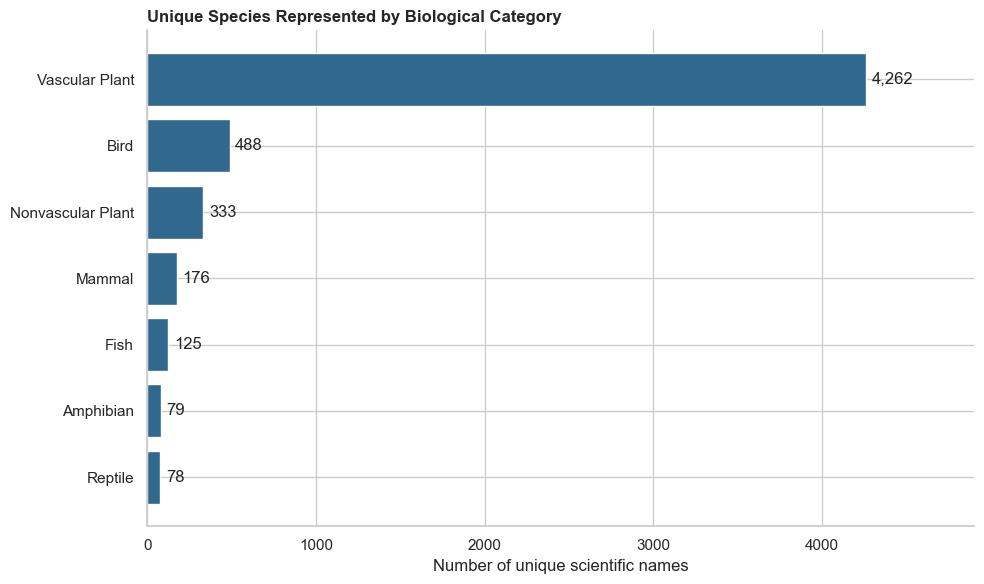

In [89]:
# Unique species by category
category_plot = (
    category_summary
    .sort_values("species_count", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    category_plot["category"],
    category_plot["species_count"],
    color=BLUE
)

ax.bar_label(
    bars,
    labels=[
        f"{value:,}"
        for value in category_plot["species_count"]
    ],
    padding=4
)

ax.set_title(
    "Unique Species Represented by Biological Category",
    loc="left",
    fontweight="bold"
)
ax.set_xlabel("Number of unique scientific names")
ax.set_ylabel("")
ax.set_xlim(
    0,
    category_plot["species_count"].max() * 1.15
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "species_by_category.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

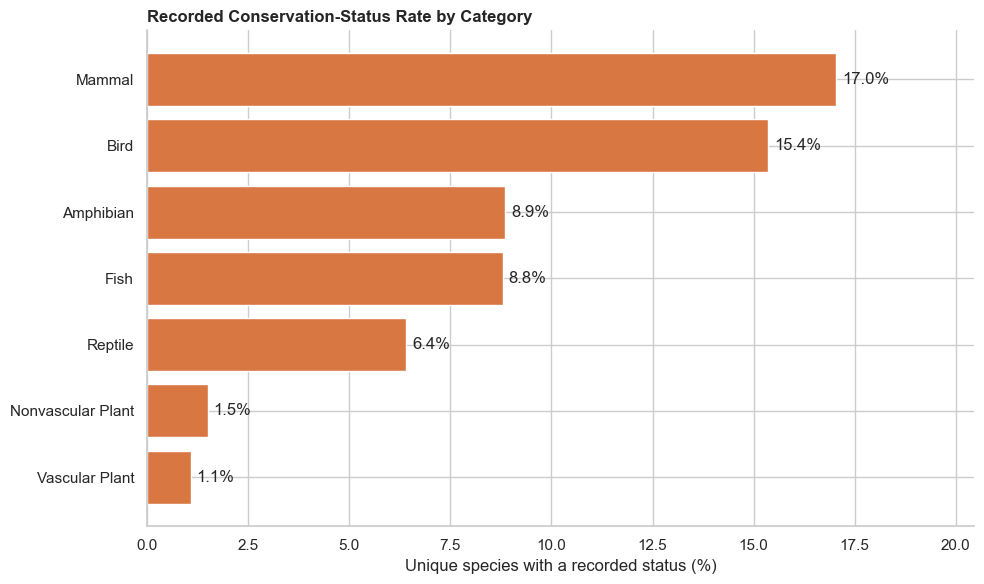

In [90]:
# Recorded conservation-status rate
rate_plot = (
    conservation_by_category
    .sort_values("recorded_status_rate", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    rate_plot["category"],
    rate_plot["recorded_status_rate"],
    color=ORANGE
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in rate_plot["recorded_status_rate"]
    ],
    padding=4
)

ax.set_title(
    "Recorded Conservation-Status Rate by Category",
    loc="left",
    fontweight="bold"
)
ax.set_xlabel(
    "Unique species with a recorded status (%)"
)
ax.set_ylabel("")
ax.set_xlim(
    0,
    rate_plot["recorded_status_rate"].max() * 1.20
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "conservation_rate_by_category.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

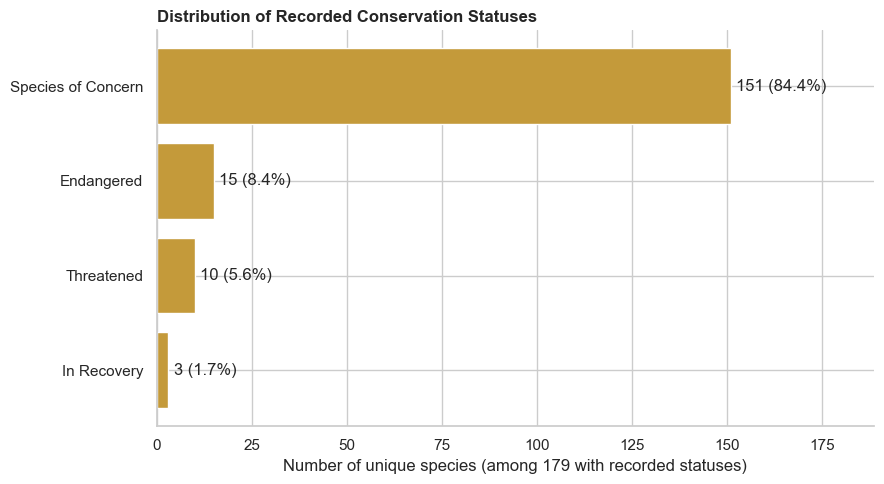

In [91]:
# Distribution among recorded statuses
status_plot = (
    recorded_status_summary
    .sort_values("species_count", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    status_plot["conservation_status"],
    status_plot["species_count"],
    color=GOLD
)

status_labels = [
    (
        f"{count:,} "
        f"({percent:.1f}%)"
    )
    for count, percent in zip(
        status_plot["species_count"],
        status_plot["percent_of_recorded_statuses"]
    )
]

ax.bar_label(
    bars,
    labels=status_labels,
    padding=4
)

ax.set_title(
    "Distribution of Recorded Conservation Statuses",
    loc="left",
    fontweight="bold"
)
ax.set_xlabel(
    "Number of unique species "
    "(among 179 with recorded statuses)"
)
ax.set_ylabel("")
ax.set_xlim(
    0,
    status_plot["species_count"].max() * 1.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "recorded_status_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

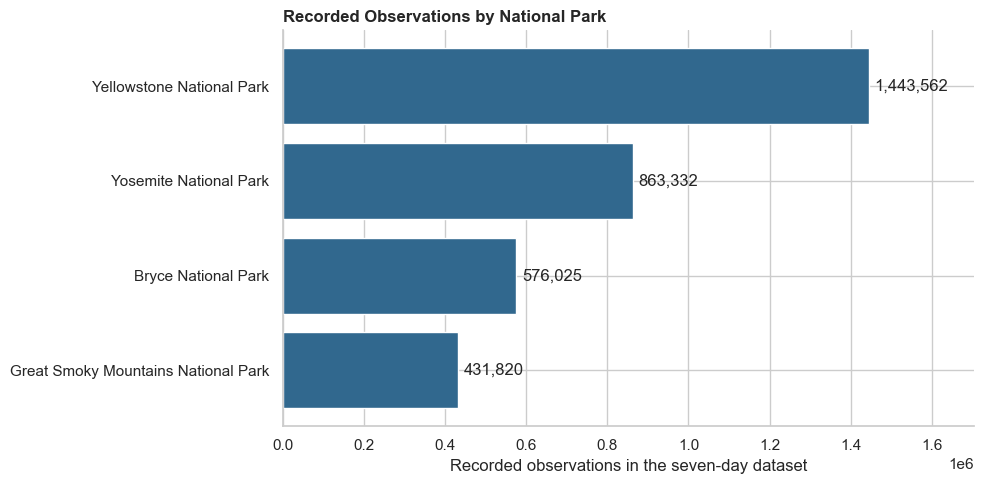

In [92]:
# Recorded observations by park
park_plot = (
    park_summary
    .sort_values("total_observations", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    park_plot["park_name"],
    park_plot["total_observations"],
    color=BLUE
)

ax.bar_label(
    bars,
    labels=[
        f"{value:,}"
        for value in park_plot["total_observations"]
    ],
    padding=4
)

ax.set_title(
    "Recorded Observations by National Park",
    loc="left",
    fontweight="bold"
)
ax.set_xlabel(
    "Recorded observations in the seven-day dataset"
)
ax.set_ylabel("")
ax.set_xlim(
    0,
    park_plot["total_observations"].max() * 1.18
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "observations_by_park.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

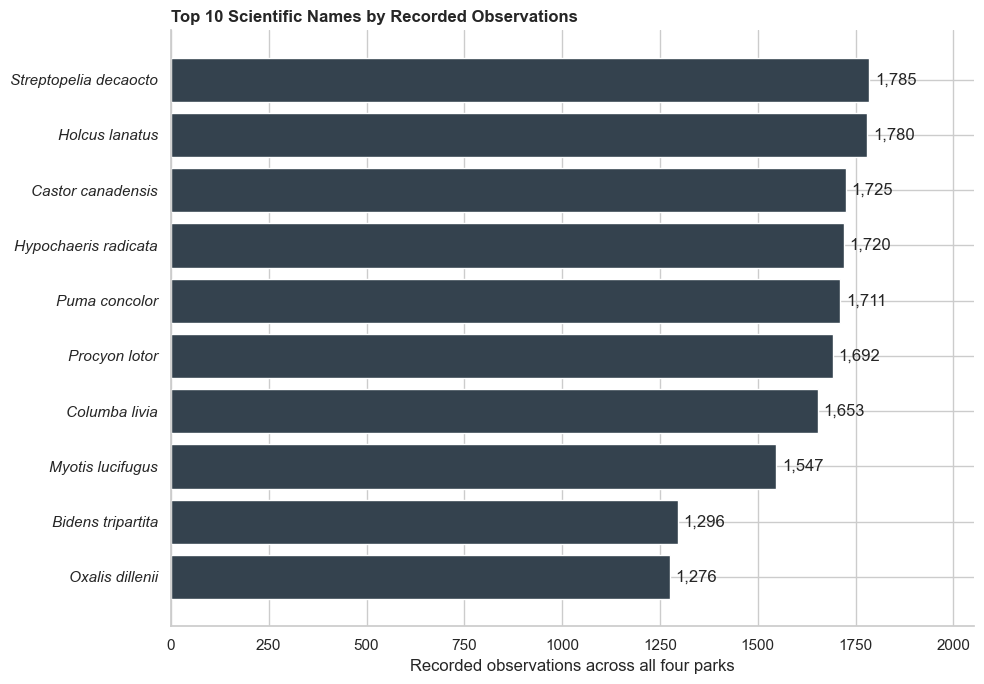

In [93]:
# Top 10 scientific names
top_species_plot = (
    top_10_species
    .sort_values("total_observations", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    top_species_plot["scientific_name"],
    top_species_plot["total_observations"],
    color=DARK_GREY
)

ax.bar_label(
    bars,
    labels=[
        f"{value:,}"
        for value in top_species_plot["total_observations"]
    ],
    padding=4
)

ax.set_title(
    "Top 10 Scientific Names by Recorded Observations",
    loc="left",
    fontweight="bold"
)
ax.set_xlabel(
    "Recorded observations across all four parks"
)
ax.set_ylabel("")
ax.set_xlim(
    0,
    top_species_plot["total_observations"].max() * 1.15
)

for label in ax.get_yticklabels():
    label.set_fontstyle("italic")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "top_10_species_observations.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

## 12. Conclusions

### Data quality

The raw species file contained 5,824 records but only 5,541 unique scientific names. A total of 274 scientific names appeared more than once, and two had conflicting conservation statuses.

A direct merge between the raw files created a many-to-many relationship, increasing the recorded observation total from 3,314,739 to 3,645,247—an inflation of 9.97%. To prevent this, the analysis created a canonical table containing one row per scientific name and aggregated observations to one row per scientific-name and park combination.

### Species composition

Vascular plants were the largest category, accounting for 4,262 of the 5,541 unique scientific names, or approximately 76.9% of the dataset. Birds were the second-largest category with 488 unique species.

These percentages describe the composition of the supplied dataset and should not be generalized to biodiversity across all National Park Service lands.

### Conservation status

A total of 179 unique species, or 3.23%, had a recorded conservation status. Species of Concern represented 151 of these species and were the most common recorded status.

Mammals had the highest recorded-status rate at 17.05%, followed by birds at 15.37%. Vascular plants had 46 species with recorded statuses, but their rate was only 1.08% because the dataset contained substantially more vascular plant species.

### Statistical comparisons

Mammals and birds had similar recorded-status rates. Fisher's exact test did not provide evidence of a meaningful difference between them (`p = 0.630`).

Mammals had approximately 2.66 times the recorded-status rate of reptiles. The unadjusted p-value was 0.029, but it increased to approximately 0.058 after correcting for two comparisons. The result was therefore treated as suggestive rather than conclusive.

These tests concern recorded conservation statuses in this dataset. They do not establish biological vulnerability or explain why the observed rates differ.

### Recorded observations

Yellowstone had the largest recorded observation total at 1,443,562, followed by Yosemite, Bryce, and Great Smoky Mountains. However, park area, survey effort, observation methods, and detection probabilities were unavailable. The totals cannot be used to rank park biodiversity, wildlife populations, or conservation performance.

Every park contained records for all 5,541 scientific names, suggesting that species coverage reflects how the fictional dataset was constructed. Consequently, the data cannot support a meaningful comparison of species richness among parks.

`Streptopelia decaocto` had the highest species-level recorded total at 1,785 observations. This identifies the largest recorded total in the dataset, not necessarily the most abundant species in the parks.

## 13. Recommendations

1. **Create reliable species and observation identifiers.** Maintain a species reference table with one row per scientific name and introduce a unique observation or survey-record identifier. Database constraints should prevent unintended duplicate keys and many-to-many joins.

2. **Track conservation-status history.** Conservation records should include the status source, effective date, jurisdiction, and last verification date. This would resolve cases where the same scientific name has conflicting statuses.

3. **Collect survey context.** Future observation data should include timestamps, geographic coordinates, observation method, survey duration, area covered, observer or sensor identifier, and sampling effort.

4. **Normalize park comparisons.** Park comparisons should account for land area and survey effort. Depending on the collection method, useful measures might include observations per survey hour, per unit area, or per standardized survey route.

5. **Validate conservation priorities using authoritative data.** Mammals and birds had the highest recorded-status rates in this dataset, but management decisions should be based on current authoritative conservation records and properly designed population-monitoring data.

6. **Investigate category differences with larger samples.** The mammal–reptile comparison was suggestive but uncertain. Additional representative data would help determine whether the observed difference is reproducible.

7. **Use reproducible data-quality checks.** Future analyses should automatically test key uniqueness, missing values, allowed conservation statuses, cross-file species coverage, observation validity, merge cardinality, and total preservation.

## 14. Limitations

- The dataset is inspired by National Park Service information but is mostly fictional.
- The observation data covers only a seven-day period.
- No observation dates or historical periods are available, so trends and seasonality cannot be analyzed.
- The data lacks park area, survey effort, observation method, and detection probability.
- An observation count may not represent unique individual organisms.
- All scientific names appear in every park, which limits species-richness analysis.
- Fifteen exact observation rows could not be classified as errors or legitimate repeated observations because no record identifiers were provided.
- Repeated species–park records were aggregated by summing their observation counts, preserving the supplied total.
- Two scientific names had conflicting statuses. The canonical table retained the more conservative status and marked the records as conflicts.
- Statistical comparisons were exploratory and do not support causal conclusions.
- The results should not be used to make real conservation or resource-allocation decisions.